# 02 — Feature Engineering

Builds the seller-order pair table (the atomic unit for every seller-level metric) and
aggregates it into one row per seller. See `src/features.py` for the implementation;
this notebook is the narrative and sensitivity analysis behind those choices.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src import clustering, config, data_loader, features, profiling

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)


In [2]:
tables, _ = data_loader.load_and_validate()
reviews_dedup = data_loader.dedupe_reviews(tables["order_reviews"])
reference_date = tables["orders"]["order_purchase_timestamp"].max()
print("reference date:", reference_date)

reference date: 2018-10-17 17:30:18


## 1. Seller-order pairs

One row = one seller's participation in one order. Aggregating straight from
`order_items` (sum per seller) would inflate frequency when a seller sells >1 item in
the same order; aggregating straight from `orders` would credit a seller with revenue
from items they didn't sell. The pair table makes both correct by construction.

In [3]:
pairs = features.build_seller_order_pairs(tables["order_items"], tables["orders"])
pairs = features.attach_review_scores(pairs, reviews_dedup)
print(f"{len(pairs):,} seller-order pairs from {tables['order_items']['order_id'].nunique():,} orders "
      f"and {pairs['seller_id'].nunique():,} sellers")
pairs.head(3)

100,010 seller-order pairs from 98,666 orders and 3,095 sellers


,seller_id,order_id,seller_revenue,seller_freight,n_items,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,895.0,21.02,1,delivered,2017-10-18 08:16:34,2017-10-27 16:46:05,2017-11-09,1.0
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,895.0,21.02,1,delivered,2017-10-12 13:33:22,2017-10-24 20:17:44,2017-11-06,5.0
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,895.0,21.02,1,delivered,2017-09-26 22:17:05,2017-10-07 16:12:47,2017-10-30,5.0


## 2. Seller-level feature matrix

In [4]:
seller_features = features.build_seller_features(pairs, reference_date)
seller_features = features.add_log_features(seller_features)
print(f"{len(seller_features):,} sellers, {seller_features['delivery_data_imputed'].sum()} with "
      f"imputed delivery metrics, {seller_features['review_data_imputed'].sum()} with imputed review rate")
seller_features[config.RAW_FEATURES + ["frequency"]].describe()

3,095 sellers, 125 with imputed delivery metrics, 5 with imputed review rate


,total_revenue,frequency,recency_days,avg_delay_days,neg_review_rate,cancel_rate,frequency
count,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000
mean,4391.484233,32.313409,185.018740,-12.212118,0.175461,0.023536,32.313409
std,13921.997192,105.139763,168.025273,7.904284,0.252011,0.125141,105.139763
min,3.500000,1.000000,44.000000,-66.000000,0.000000,0.000000,1.000000
25%,208.850000,2.000000,62.000000,-15.000000,0.000000,0.000000,2.000000
50%,821.480000,6.000000,95.000000,-11.875000,0.100000,0.000000,6.000000
75%,3280.830000,21.500000,265.500000,-9.224747,0.212444,0.000000,21.500000
max,229472.630000,1854.000000,744.000000,167.000000,1.000000,1.000000,1854.000000


## 3. Minimum-order threshold: sensitivity analysis

Sellers with 1-2 orders have degenerate rate features -- a negative-review rate can only
land on 0%, 50% or 100%. The question is where to draw the line, and what it costs in
revenue coverage.

In [5]:
sens = features.threshold_sensitivity(seller_features)
sens

,threshold,sellers_kept,sellers_kept_pct,revenue_kept_pct
0,1,3095,100.0,100.0
1,2,2524,81.6,99.0
2,3,2171,70.1,97.9
3,5,1794,58.0,95.8
4,10,1271,41.1,90.6
5,15,983,31.8,86.1
6,20,818,26.4,82.1


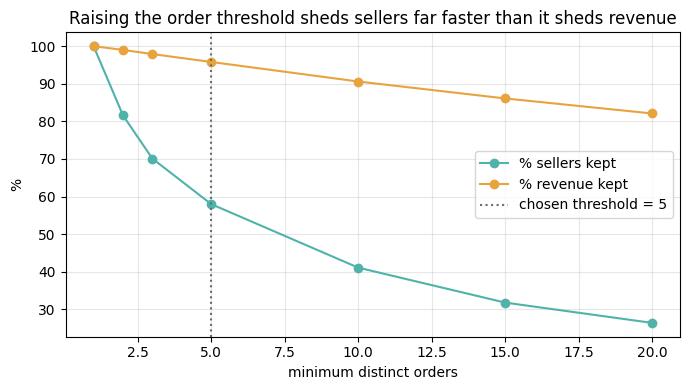

In [6]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sens["threshold"], sens["sellers_kept_pct"], "o-", color="#4FB3A9", label="% sellers kept")
ax1.plot(sens["threshold"], sens["revenue_kept_pct"], "o-", color="#E8A33D", label="% revenue kept")
ax1.axvline(config.MIN_ORDERS_THRESHOLD, color="#666C79", linestyle=":", label=f"chosen threshold = {config.MIN_ORDERS_THRESHOLD}")
ax1.set_xlabel("minimum distinct orders")
ax1.set_ylabel("%")
ax1.legend()
ax1.set_title("Raising the order threshold sheds sellers far faster than it sheds revenue")
plt.tight_layout()
plt.show()

At the chosen threshold (**≥5 orders**, `config.MIN_ORDERS_THRESHOLD`), the eligible
population keeps **58.0% of sellers** but **95.8% of revenue** -- the model covers the
overwhelming majority of GMV while dropping the half of the base whose rate-based
features would otherwise be noise. The excluded ~42% are not discarded from the project:
they become the "New / Low Data" bucket in the business layer (`profiling.py`,
`cluster_profiles.json`), so every seller still gets a profile.

## 4. Threshold split

In [7]:
eligible, excluded = features.apply_min_order_threshold(seller_features)
print(f"eligible: {len(eligible):,} sellers -- excluded (new/low data): {len(excluded):,} sellers")

eligible: 1,794 sellers -- excluded (new/low data): 1,301 sellers


## 5. Cancel rate: denominator matters

Computed over **every** seller-order pair, before any delivered-only filter -- filtering to delivered orders first would divide by the wrong denominator and hide cancellations entirely.

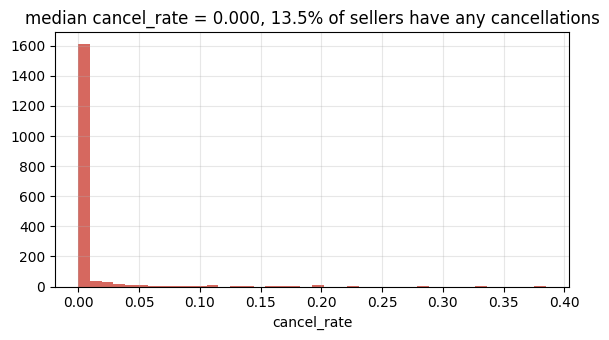

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(eligible["cancel_rate"], bins=40, color="#D6685F")
ax.set_xlabel("cancel_rate")
ax.set_title(f"median cancel_rate = {eligible['cancel_rate'].median():.3f}, "
             f"{100*(eligible['cancel_rate'] > 0).mean():.1f}% of sellers have any cancellations")
plt.tight_layout()
plt.show()

## Next

`03_clustering.ipynb` takes `eligible` from here, checks feature correlation, selects k, stress-tests with DBSCAN, and fits the final segmentation.